In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform
from scikeras.wrappers import KerasRegressor

random_state = 42

Loading and Preprocessing the Data


In [13]:
# Load the dataset
power_df = pd.read_csv("Tetuan City power consumption.csv")

# Display the first few rows to understand the structure
power_df.sample(n=5, random_state=random_state)

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
15506,4/18/2017 16:20,22.76,29.73,0.085,615.500,664.800,32985.14532,19396.74134,17623.27273
51943,12/27/2017 17:10,15.92,54.44,0.085,19.120,19.340,34737.64259,29803.00706,14417.28691
212,1/2/2017 11:20,15.08,57.23,0.076,396.600,40.660,27894.68354,20808.51064,16458.79518
11210,3/19/2017 20:20,12.42,72.30,0.081,0.062,0.148,42476.93617,23634.14634,25089.67742
16307,4/24/2017 5:50,14.58,80.60,0.080,0.018,0.204,21341.14101,12006.10998,11531.63636


In [14]:
power_df.rename(
    columns={
        "Zone 1 Power Consumption": "Quads",
        "Zone 2  Power Consumption": "Smir",
        "Zone 3  Power Consumption": "Boussafou",
        "diffuse flows": "Diffuse flows",
        "general diffuse flows": "Global Diffuse",
    },
    inplace=True,
)
power_df.head()

,DateTime,Temperature,Humidity,Wind Speed,Global Diffuse,Diffuse flows,Quads,Smir,Boussafou
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [15]:
# Check for missing values
power_df.isnull().sum()

DateTime          0
Temperature       0
Humidity          0
Wind Speed        0
Global Diffuse    0
Diffuse flows     0
Quads             0
Smir              0
Boussafou         0
dtype: int64

In [16]:
# Convert date-time if applicable and create additional features
power_df["DateTime"] = pd.to_datetime(power_df["DateTime"])

power_df["Day"] = power_df["DateTime"].dt.day
power_df["Month"] = power_df["DateTime"].dt.month
power_df["Day of Month"] = power_df["DateTime"].dt.day
power_df["Hour"] = power_df["DateTime"].dt.hour
power_df["Day of Year"] = power_df["DateTime"].dt.dayofyear
power_df["Week of Year"] = power_df["DateTime"].dt.isocalendar().week
power_df["Day of Week"] = power_df["DateTime"].dt.dayofweek
power_df["Quarter"] = power_df["DateTime"].dt.quarter
power_df["Minute"] = power_df["DateTime"].dt.minute

power_df.sample(n=5, random_state=random_state)

,DateTime,Temperature,Humidity,Wind Speed,Global Diffuse,Diffuse flows,Quads,Smir,Boussafou,Day,Month,Day of Month,Hour,Day of Year,Week of Year,Day of Week,Quarter,Minute
15506,2017-04-18 16:20:00,22.76,29.73,0.085,615.500,664.800,32985.14532,19396.74134,17623.27273,18,4,18,16,108,16,1,2,20
51943,2017-12-27 17:10:00,15.92,54.44,0.085,19.120,19.340,34737.64259,29803.00706,14417.28691,27,12,27,17,361,52,2,4,10
212,2017-01-02 11:20:00,15.08,57.23,0.076,396.600,40.660,27894.68354,20808.51064,16458.79518,2,1,2,11,2,1,0,1,20
11210,2017-03-19 20:20:00,12.42,72.30,0.081,0.062,0.148,42476.93617,23634.14634,25089.67742,19,3,19,20,78,11,6,1,20
16307,2017-04-24 05:50:00,14.58,80.60,0.080,0.018,0.204,21341.14101,12006.10998,11531.63636,24,4,24,5,114,17,0,2,50


Exploratory Data Analysis (EDA)


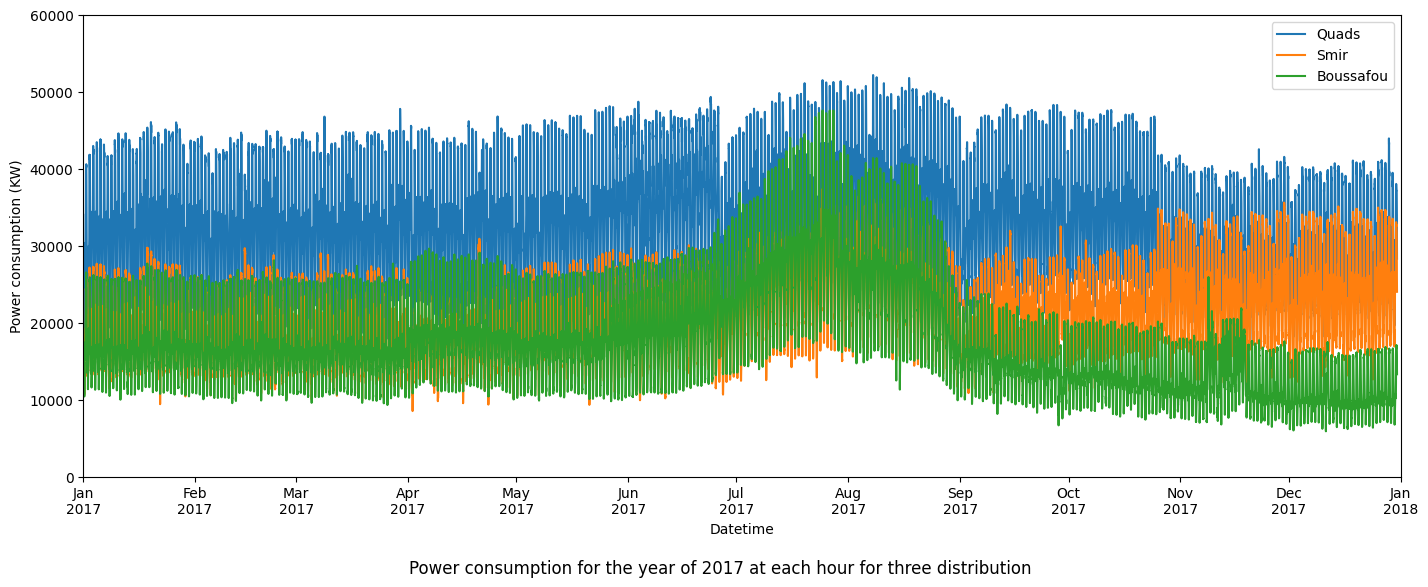

In [17]:
# Create the figure and axes
fig, ax = plt.subplots(figsize=(17, 6))

# Plot the data
ax.plot(
    power_df["DateTime"],
    power_df["Quads"],
    label="Quads",
    color="#1f77b4",
)
ax.plot(
    power_df["DateTime"],
    power_df["Smir"],
    label="Smir",
    color="#ff7f0e",
)
ax.plot(
    power_df["DateTime"],
    power_df["Boussafou"],
    label="Boussafou",
    color="#2ca02c",
)

# Set x-axis and y-axis labels
ax.set_xlabel("Datetime")
ax.set_ylabel("Power consumption (KW)")

# Set x-axis limits
ax.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2018-01-01"))

# Format x-axis ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Set y-axis limits
ax.set_ylim(0, 60000)

# Add legend
ax.legend()

plt.figtext(
    0.5,
    -0.05,
    "Power consumption for the year of 2017 at each hour for three distribution",
    ha="center",
    fontsize=12,
)


# Show the plot
plt.show()

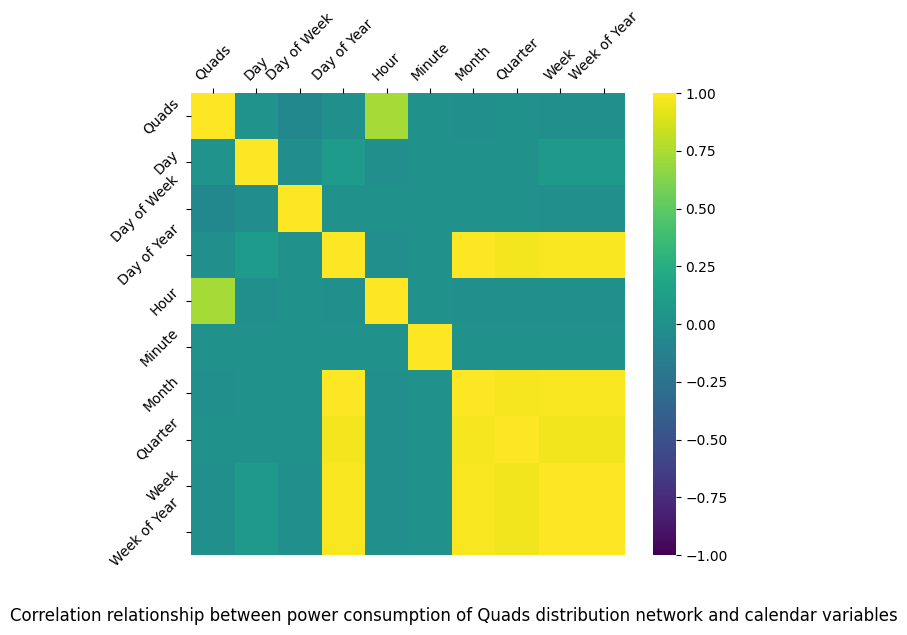

In [18]:
col = [
    "Quads",
    "Day",
    "Day of Week",
    "Day of Year",
    "Hour",
    "Minute",
    "Month",
    "Quarter",
    "Week of Year",
    "Week of Year",
]
corr_matrix = power_df[col].corr()

label = [
    "Quads",
    "Day",
    "Day of Week",
    "Day of Year",
    "Hour",
    "Minute",
    "Month",
    "Quarter",
    "Week",
    "Week of Year",
]

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, cmap="viridis", annot=False, vmin=-1, vmax=1)

# Set axis labels
plt.xticks(ticks=np.arange(len(col)) + 0.5, labels=label, rotation=45)
plt.yticks(ticks=np.arange(len(col)) + 0.5, labels=label, rotation=45)

# Set title below the plot
plt.figtext(
    0.5,
    0,
    "Correlation relationship between power consumption of Quads distribution network and calendar variables",
    ha="center",
    fontsize=12,
)

# Move x-axis ticks to the top
ax = plt.gca()
ax.xaxis.tick_top()

plt.show()

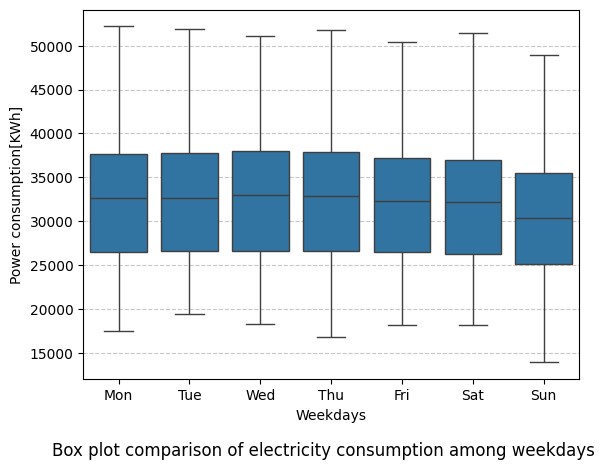

In [19]:
# Create the boxplot
sns.boxplot(data=power_df, x="Day of Week", y="Quads")

# Customize x-ticks
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.xlabel("Weekdays")
plt.ylabel("Power consumption[KWh]")
plt.figtext(
    0.5,
    -0.05,
    "Box plot comparison of electricity consumption among weekdays",
    ha="center",
    fontsize=12,
)

plt.show()

In [20]:
col = [
    "Quads",
    "Temperature",
    "Humidity",
    "Wind Speed",
    "Diffuse flows",
    "Global Diffuse",
]

# Calculate descriptive statistics with desired columns
summary_stats = power_df[col].describe()

# Select specific statistics
summary_stats = summary_stats.loc[["count", "mean", "std", "min", "max"]]

# Add correlation as a new row
summary_stats.loc["correlation"] = power_df[col].corr().mean().mean()

summary_stats.T

,count,mean,std,min,max,correlation
Quads,52416.0,32344.970564,7130.562564,13895.6962,52204.39512,0.227709
Temperature,52416.0,18.810024,5.815476,3.2470,40.01000,0.227709
Humidity,52416.0,68.259518,15.551177,11.3400,94.80000,0.227709
Wind Speed,52416.0,1.959489,2.348862,0.0500,6.48300,0.227709
Diffuse flows,52416.0,75.028022,124.210949,0.0110,936.00000,0.227709
Global Diffuse,52416.0,182.696614,264.400960,0.0040,1163.00000,0.227709


In [21]:
# Split features and targets
features = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "Global Diffuse",
    "Diffuse flows",
    "Day",
    "Month",
    "Day of Month",
    "Hour",
    "Day of Year",
    "Week of Year",
    "Day of Week",
    "Quarter",
    "Minute",
]
targets = ["Quads", "Smir", "Boussafou"]

X = power_df[features]
y = power_df[targets]

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# # Split data into train and test sets (75% train, 25% test)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.25, random_state=random_state
# )

In [22]:
def create_ffnn_model(input_dim):
    model = Sequential(
        [
            Input(shape=(input_dim,)),  # Define the input shape here
            Dense(
                10,
                activation="selu",
                kernel_initializer=GlorotUniform(),
            ),
            Dense(1),  # Output layer
        ]
    )

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss="mean_squared_error")

    return model


# Function to perform MCCV with GridSearchCV
def monte_carlo_cv_gridsearch(
    new_X, new_y, model, param_grid, model_name, n_iterations=9, test_size=0.25
):
    mae_train_list = []
    mae_test_list = []
    rmse_train_list = []
    rmse_test_list = []

    # Initialize Monte Carlo cross-validation
    mccv = ShuffleSplit(
        n_splits=n_iterations, test_size=test_size, random_state=random_state
    )

    # Loop over each Monte Carlo split
    for train_idx, test_idx in mccv.split(new_X, new_y):
        X_train, X_test = new_X.iloc[train_idx], new_X.iloc[test_idx]
        y_train, y_test = new_y.iloc[train_idx], new_y.iloc[test_idx]

        grid_search = GridSearchCV(
            model,
            param_grid[model_name],
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
        )
        grid_search.fit(X_train, y_train)

        print(
            f"Best hyperparameters that can be used for {model_name} => {grid_search.best_params_}"
        )
        best_model = grid_search.best_estimator_

        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        rmse_train_list.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
        mae_train_list.append(mean_absolute_error(y_train, y_pred_train))
        rmse_test_list.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
        mae_test_list.append(mean_absolute_error(y_test, y_pred_test))

    return (
        np.median(rmse_train_list),
        np.median(mae_train_list),
        np.median(rmse_test_list),
        np.median(mae_test_list),
    )


# Define models
rf = RandomForestRegressor(random_state=random_state)
dt = DecisionTreeRegressor(random_state=random_state)
svr = SVR(kernel="rbf")
nn = KerasRegressor(build_fn=lambda: create_ffnn_model(X.shape[1]), verbose=0)
lr = LinearRegression()

models = [rf, dt, svr, nn, lr]
model_names = [
    "Random Forest",
    "Decision Tree",
    "SVR",
    "Neural Network",
    "Linear Regression",
]
model_param_details = {
    "Random Forest": {
        "n_estimators": [30, 70, 100],
        "max_features": [5, 6, 7],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 4],
        "min_samples_leaf": [1, 2],
    },
    "Decision Tree": {
        "min_samples_split": [9, 10, 11],
        "min_samples_leaf": [7, 8, 9],
        "max_features": [7, 8, 9],
    },
    "SVR": {"C": [1, 10, 100, 1000], "gamma": [0.01, 0.001, 0.0001]},
    "Linear Regression": {"alpha": [0.1, 1, 10, 100]},
    "Neural Network": {
        "batch_size": [10, 20],
        "epochs": [50, 100],
    },
}

results = {}

for target in targets:
    print(f"Start mode for target => {target}")
    results[target] = {}
    for model, name in zip(models, model_names):
        print(f"Start mode => {name}")
        rmse_train, mae_train, rmse_test, mae_test = monte_carlo_cv_gridsearch(
            X_scaled, y[target], model, model_param_details, name
        )

        results[target][name] = {
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
        }
        print(f"End mode => {name}\n")
    print(f"End mode for target => {target}\n\n")

Start mode for target => Quads
Start mode => Random Forest
Best hyperparameters that can be used for Random Forest => {'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best hyperparameters that can be used for Random Forest => {'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best hyperparameters that can be used for Random Forest => {'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best hyperparameters that can be used for Random Forest => {'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best hyperparameters that can be used for Random Forest => {'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best hyperparameters that can be used for Random Forest => {'max_depth': None, 'max_features': 7, 'min_samples_

KeyboardInterrupt: 

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    if name == "Neural Network":
        model.fit(X_train, y_train, epochs=100, verbose=0)
    else:
        grid_search = GridSearchCV(model, model_param_details[name], cv=5, n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best hyperparameters that can be used => {grid_search.best_params_}")
        model = grid_search.best_estimator_
        model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)

    return rmse_train, mae_train, rmse_test, mae_test

# Re-Define models
rf = RandomForestRegressor(random_state=random_state,max_depth= None, max_features= 7, min_samples_leaf= 1,min_samples_split= 2, n_estimators=100)
dt = DecisionTreeRegressor(random_state=random_state,max_features= 9, min_samples_leaf= 7, min_samples_split= 9)
svr = SVR(kernel="rbf",C= 1000, gamma= 0.01)
nn = KerasRegressor(build_fn=lambda: create_ffnn_model(X.shape[1]), verbose=0)
lr = LinearRegression()

models = [rf, dt, svr, nn, lr]

results = {}

for target in targets:
    print(f"Start mode for target => {target}")
    results[target] = {}
    for model, name in zip(models, model_names):
        print(f"Start mode => {name}")
        rmse_train, mae_train, rmse_test, mae_test = monte_carlo_cv_gridsearch(
            X_scaled, y[target], model, model_param_details, name
        )

        results[target][name] = {
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
        }
        print(f"End mode => {name}\n")
    print(f"End mode for target => {target}\n\n")

In [ ]:
# Print results
for target in targets:
    print(f"\nResults for {target}:")
    for model in model_names:
        print(f"{model}:")
        print(f"  RMSE Train: {results[target][model]['RMSE Train']:.2f}")
        print(f"  MAE Train: {results[target][model]['MAE Train']:.2f}")
        print(f"  RMSE Test: {results[target][model]['RMSE Test']:.2f}")
        print(f"  MAE Test: {results[target][model]['MAE Test']:.2f}")

In [ ]:
# Feature engineering
def create_time_features(X):
    X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
    X["day_sin"] = np.sin(2 * np.pi * X["day_of_week"] / 7)
    X["day_cos"] = np.cos(2 * np.pi * X["day_of_week"] / 7)
    X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
    X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
    return X


X_engineered = create_time_features(X.copy())

# Create a pipeline with feature selection, polynomial features, and gradient boosting
pipeline = Pipeline(
    [
        ("feature_selection", SelectKBest(f_regression, k=10)),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        (
            "gb",
            GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
            ),
        ),
    ]
)

# Evaluate the new model
results_new = {}
for target in targets:
    rmse_train, mae_train, rmse_test, mae_test = evaluate_model(
        pipeline, X_engineered, X_engineered, y[target], y[target]
    )
    results_new[target] = {
        "RMSE Train": rmse_train,
        "MAE Train": mae_train,
        "RMSE Test": rmse_test,
        "MAE Test": mae_test,
    }

# Print results of the new model
for target in targets:
    print(f"\nResults for {target} (New Model):")
    print(f"  RMSE Train: {results_new[target]['RMSE Train']:.2f}")
    print(f"  MAE Train: {results_new[target]['MAE Train']:.2f}")
    print(f"  RMSE Test: {results_new[target]['RMSE Test']:.2f}")
    print(f"  MAE Test: {results_new[target]['MAE Test']:.2f}")